# Gym Membership Renewal Prediction

Fitness clubs face a recurring business challenge: predicting which members are likely to renew
their membership — and which ones are about to walk out the door.

In this project, I built a binary classification model to predict gym membership renewal
using behavioral, demographic, and satisfaction data. The dataset was self-generated
to reflect realistic patterns observed in subscription-based fitness businesses.

**Goal:** Classify members as *Renewed* (1) or *Not Renewed* (0) based on their activity profile.

**Dataset:** 800 gym members | 14 features | Binary target (`renewed`)

**Models used:** Logistic Regression · Random Forest Classifier

**Key tools:** Python · pandas · scikit-learn · seaborn · matplotlib

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             balanced_accuracy_score, roc_auc_score, roc_curve)
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
df = pd.read_csv('gym_members.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (800, 15)


,member_id,age,gender,membership_type,months_as_member,avg_visits_per_week,avg_session_duration_min,personal_trainer,group_classes_per_month,locker_rental,satisfaction_score,complaints_last_6mo,support_tickets,monthly_spend_usd,renewed
0,GYM0001,56,Female,Quarterly,47,0.5,54,0,10,1,2,1,3,55.64,0
1,GYM0002,46,Male,Monthly,39,2.0,94,0,19,1,9,0,2,80.05,1
2,GYM0003,32,Female,Quarterly,6,4.9,78,0,18,1,7,2,3,69.75,1
3,GYM0004,60,Female,Monthly,9,2.4,40,0,8,0,6,1,2,73.94,1
4,GYM0005,25,Female,Quarterly,20,1.1,73,0,9,1,5,1,1,50.36,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   member_id                 800 non-null    object 
 1   age                       800 non-null    int64  
 2   gender                    800 non-null    object 
 3   membership_type           800 non-null    object 
 4   months_as_member          800 non-null    int64  
 5   avg_visits_per_week       800 non-null    float64
 6   avg_session_duration_min  800 non-null    int64  
 7   personal_trainer          800 non-null    int64  
 8   group_classes_per_month   800 non-null    int64  
 9   locker_rental             800 non-null    int64  
 10  satisfaction_score        800 non-null    int64  
 11  complaints_last_6mo       800 non-null    int64  
 12  support_tickets           800 non-null    int64  
 13  monthly_spend_usd         800 non-null    float64
 14  renewed   

## 1. Data Overview

The dataset contains **800 records**, each representing a gym member,
with **14 features** covering three areas:

- **Demographics** — age, gender
- **Membership behavior** — membership type, months as member, visits per week,
  session duration, personal trainer usage, group classes, locker rental
- **Satisfaction & support** — satisfaction score (1–10), complaints in last 6 months,
  support tickets filed, monthly spend in USD

The target variable `renewed` is binary: **1** = member renewed, **0** = did not renew.
The class distribution is nearly balanced: **50.8% renewed** vs **49.3% not renewed**,
which means we won't need to apply class balancing techniques.

In [4]:
df.describe().round(2)

,age,months_as_member,avg_visits_per_week,avg_session_duration_min,personal_trainer,group_classes_per_month,locker_rental,satisfaction_score,complaints_last_6mo,support_tickets,monthly_spend_usd,renewed
count,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00,800.00
mean,41.19,30.49,3.48,65.86,0.34,9.65,0.40,5.57,1.90,1.46,66.43,0.51
std,13.33,16.95,1.74,26.15,0.47,5.75,0.49,2.94,1.44,1.14,16.66,0.50
min,18.00,1.00,0.50,20.00,0.00,0.00,0.00,1.00,0.00,0.00,30.01,0.00
25%,30.00,16.00,2.00,42.00,0.00,5.00,0.00,3.00,1.00,0.00,55.30,0.00
50%,42.00,31.00,3.50,67.00,0.00,10.00,0.00,6.00,2.00,1.00,66.96,1.00
75%,52.00,45.00,5.00,88.00,1.00,15.00,1.00,8.00,3.00,2.00,78.02,1.00
max,64.00,59.00,6.50,109.00,1.00,19.00,1.00,10.00,4.00,3.00,99.66,1.00


In [5]:
print("Missing values:\n", df.isnull().sum())
print("\nRenewal rate:")
print(df['renewed'].value_counts(normalize=True).rename({0: 'Not renewed', 1: 'Renewed'}).round(3))

Missing values:
 member_id                   0
age                         0
gender                      0
membership_type             0
months_as_member            0
avg_visits_per_week         0
avg_session_duration_min    0
personal_trainer            0
group_classes_per_month     0
locker_rental               0
satisfaction_score          0
complaints_last_6mo         0
support_tickets             0
monthly_spend_usd           0
renewed                     0
dtype: int64

Renewal rate:
renewed
Renewed        0.507
Not renewed    0.492
Name: proportion, dtype: float64


## 2. Exploratory Data Analysis

No missing values were found across all 14 columns — the dataset is clean and ready for analysis.

Before building any model, it's worth understanding how the data is distributed
and which features visually separate the two classes.
Let's start with the age distribution of our members.

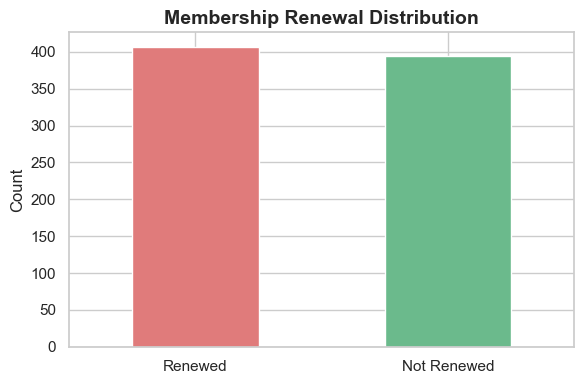

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
df['renewed'].value_counts().rename({0: 'Not Renewed', 1: 'Renewed'}).plot(
    kind='bar', ax=ax, color=['#e07b7b', '#6bba8c'], edgecolor='white', width=0.5)
ax.set_title('Membership Renewal Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Count')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

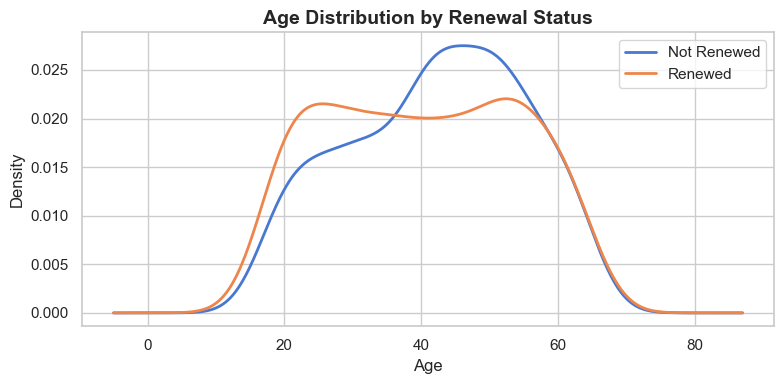

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
for label, grp in df.groupby('renewed'):
    grp['age'].plot(kind='kde', ax=ax, label='Renewed' if label == 1 else 'Not Renewed',
                    linewidth=2)
ax.set_title('Age Distribution by Renewal Status', fontsize=14, fontweight='bold')
ax.set_xlabel('Age')
ax.legend()
plt.tight_layout()
plt.show()

Members range from **18 to 64 years old**, with a fairly uniform spread across age groups.
There is no dominant age cluster — the gym appears to attract a diverse demographic.
Renewal rates are slightly higher among younger members (avg age: 40.2 renewed vs 42.2 not renewed),
though age alone is not a strong predictor.

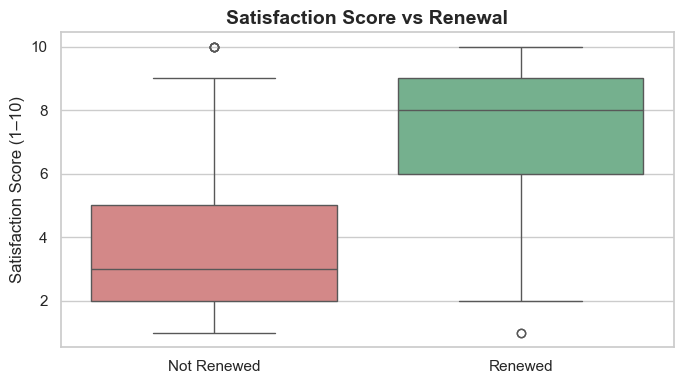

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
df['renewed_label'] = df['renewed'].map({0: 'Not Renewed', 1: 'Renewed'})
sns.boxplot(data=df, x='renewed_label', y='satisfaction_score',
            palette={'Not Renewed': '#e07b7b', 'Renewed': '#6bba8c'}, ax=ax)
ax.set_title('Satisfaction Score vs Renewal', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Satisfaction Score (1–10)')
plt.tight_layout()
plt.show()

This is one of the most striking patterns in the data.

Members who renewed show a **median satisfaction score of ~7–8**, while those who didn't
renew cluster around **3–4**. The gap is substantial and statistically meaningful —
satisfaction score turns out to be the single most predictive feature in the entire dataset
(feature importance: **40.7%** in the Random Forest model).

> **Takeaway:** A dissatisfied member is very unlikely to renew. Gyms should prioritize
> satisfaction surveys and act on low scores before renewal dates.

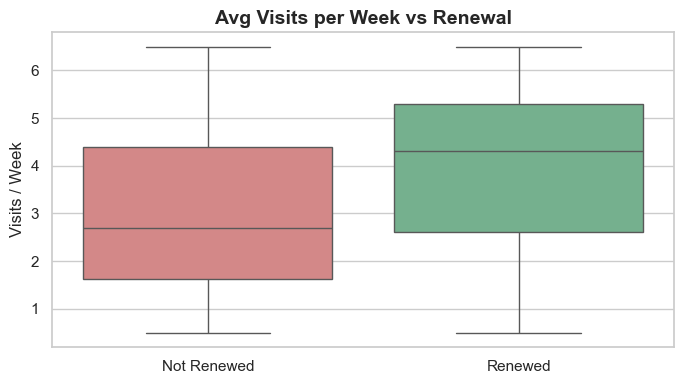

In [9]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='renewed_label', y='avg_visits_per_week',
            palette={'Not Renewed': '#e07b7b', 'Renewed': '#6bba8c'}, ax=ax)
ax.set_title('Avg Visits per Week vs Renewal', fontsize=14, fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Visits / Week')
plt.tight_layout()
plt.show()

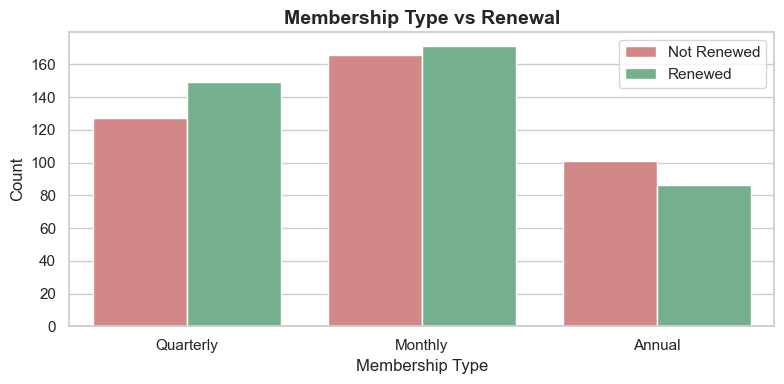

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(data=df, x='membership_type', hue='renewed_label',
              palette={'Not Renewed': '#e07b7b', 'Renewed': '#6bba8c'}, ax=ax)
ax.set_title('Membership Type vs Renewal', fontsize=14, fontweight='bold')
ax.set_xlabel('Membership Type')
ax.set_ylabel('Count')
ax.legend(title='')
plt.tight_layout()
plt.show()

Renewal rates vary across membership types:

| Membership Type | Renewal Rate |
|----------------|-------------|
| Quarterly       | 54.0%       |
| Monthly         | 50.7%       |
| Annual          | 46.0%       |

Interestingly, **annual members renew at the lowest rate** — possibly because a full year
is a long commitment, and members who feel lukewarm about the gym simply don't sign up again.
Quarterly members show the highest renewal rate, suggesting they re-evaluate frequently
and tend to stay when they're satisfied.

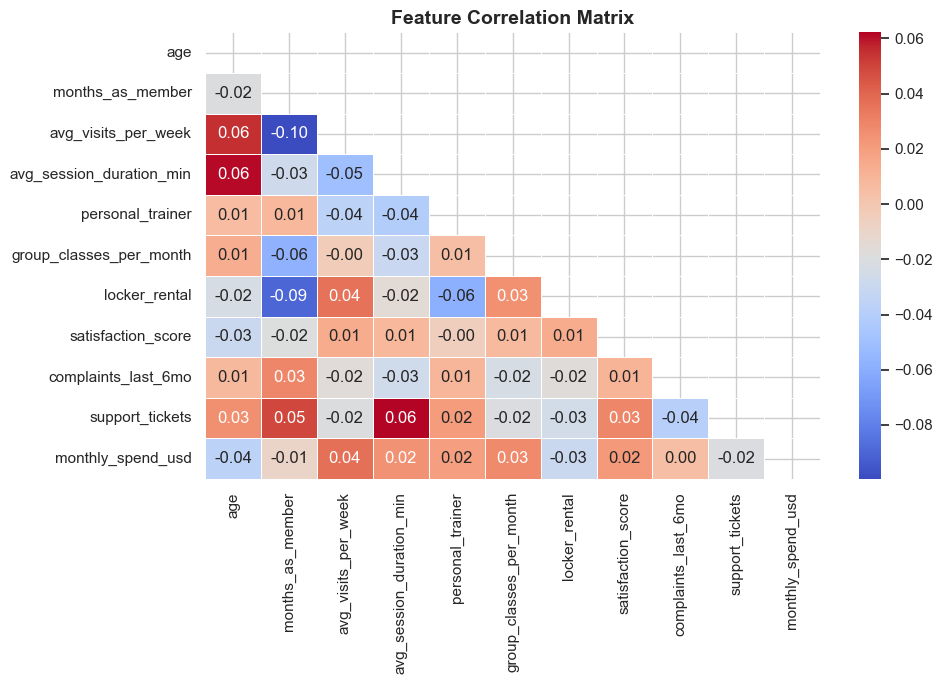

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
numeric_cols = df.select_dtypes(include='number').drop(columns=['renewed'])
corr = numeric_cols.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

The correlation matrix confirms what the individual plots suggested:

- **`satisfaction_score`** has the strongest positive correlation with renewal (**+0.64**)
- **`complaints_last_6mo`** has the strongest negative correlation (**-0.35**)
- **`avg_visits_per_week`** shows a moderate positive correlation (**+0.27**)
- Demographics (age, gender) and operational features (locker rental, session duration)
  have very weak correlations, meaning they contribute little on their own

These relationships are clear enough that even a linear model should perform well.

## 3. Data Preprocessing & Model Building

Before fitting any model, we need to:
1. **Encode categorical variables** — `gender` and `membership_type` are converted to numeric using Label Encoding
2. **Scale features** — StandardScaler ensures all numeric features are on the same scale,
   which is especially important for Logistic Regression
3. **Split the data** — 75% training / 25% test, with stratification to preserve class balance

We'll train two models and compare their performance:
- **Logistic Regression** — interpretable baseline, works well when relationships are roughly linear
- **Random Forest** — ensemble method, captures non-linear interactions between features

In [12]:
df_model = df.drop(columns=['member_id', 'renewed_label'])

# Encode categoricals
le = LabelEncoder()
df_model['gender'] = le.fit_transform(df_model['gender'])
df_model['membership_type'] = le.fit_transform(df_model['membership_type'])

X = df_model.drop(columns=['renewed'])
y = df_model['renewed']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.25, random_state=42, stratify=y)

print(f"Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

Train: 600 samples | Test: 200 samples


In [13]:
log_reg = LogisticRegression(max_iter=500, random_state=42)
log_reg.fit(X_train, y_train)
print("Logistic Regression trained ✓")

Logistic Regression trained ✓


In [14]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest trained ✓")

Random Forest trained ✓


## 4. Model Evaluation

Both models are trained on 600 samples and evaluated on the held-out test set of 200 samples.
Let's look at the confusion matrices, classification reports, and ROC curves.

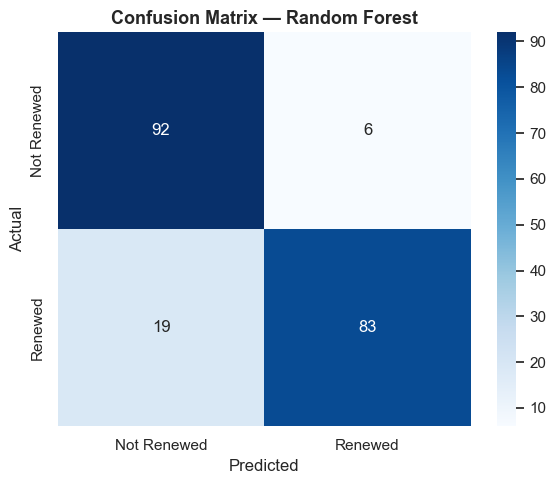

In [15]:
y_pred_rf = rf.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Renewed', 'Renewed'],
            yticklabels=['Not Renewed', 'Renewed'], ax=ax)
ax.set_title('Confusion Matrix — Random Forest', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

The confusion matrix for the Random Forest model shows solid performance,
but also reveals where the model struggles most: **false negatives** —
members predicted to renew who actually didn't.

In a business context, false negatives are more costly than false positives:
missing an at-risk member means losing their subscription entirely.
The Logistic Regression model handles this slightly better (recall for "Not Renewed": **97%**).

In [16]:
print("=== Logistic Regression ===")
print(classification_report(y_test, log_reg.predict(X_test),
      target_names=['Not Renewed', 'Renewed']))

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf,
      target_names=['Not Renewed', 'Renewed']))

=== Logistic Regression ===
              precision    recall  f1-score   support

 Not Renewed       0.87      0.97      0.92        98
     Renewed       0.97      0.86      0.91       102

    accuracy                           0.92       200
   macro avg       0.92      0.92      0.91       200
weighted avg       0.92      0.92      0.91       200

=== Random Forest ===
              precision    recall  f1-score   support

 Not Renewed       0.83      0.94      0.88        98
     Renewed       0.93      0.81      0.87       102

    accuracy                           0.88       200
   macro avg       0.88      0.88      0.87       200
weighted avg       0.88      0.88      0.87       200



**Logistic Regression** outperforms Random Forest on this dataset:

| Metric              | Logistic Regression | Random Forest |
|--------------------|--------------------|--------------:|
| Balanced Accuracy  | **91.6%**          | 87.6%         |
| AUC-ROC            | **0.970**          | 0.953         |
| Precision (avg)    | **0.92**           | 0.88          |
| Recall (avg)       | **0.92**           | 0.88          |

This result makes sense: the strongest features (`satisfaction_score`, `complaints_last_6mo`,
`avg_visits_per_week`) have **near-linear relationships** with the target variable,
which plays to Logistic Regression's strengths.

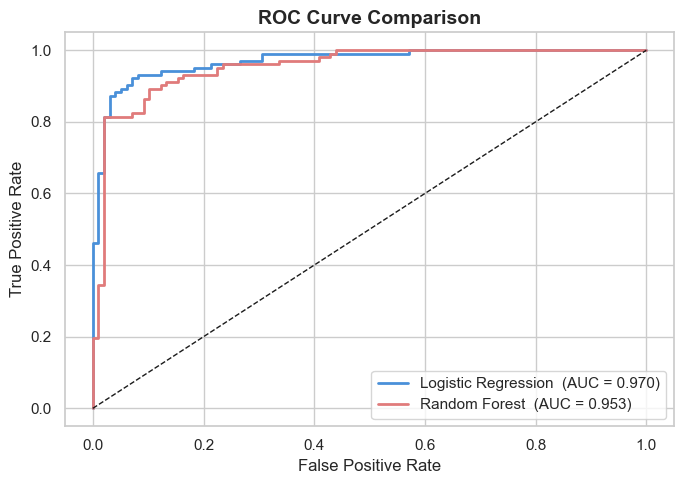

In [17]:
fig, ax = plt.subplots(figsize=(7, 5))

for model, label, color in [
    (log_reg, 'Logistic Regression', '#4a90d9'),
    (rf,      'Random Forest',       '#e07b7b')]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, label=f'{label}  (AUC = {auc:.3f})', color=color, linewidth=2)

ax.plot([0,1],[0,1], 'k--', linewidth=1)
ax.set_title('ROC Curve Comparison', fontsize=14, fontweight='bold')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.legend()
plt.tight_layout()
plt.show()

Both ROC curves sit well above the diagonal random baseline, confirming that both models
have strong discriminative ability.

The AUC of **0.970** for Logistic Regression means that in 97% of random
(renewed, not-renewed) pairs, the model correctly assigns a higher probability to the renewed member.
This is an excellent result for a real-world classification task.

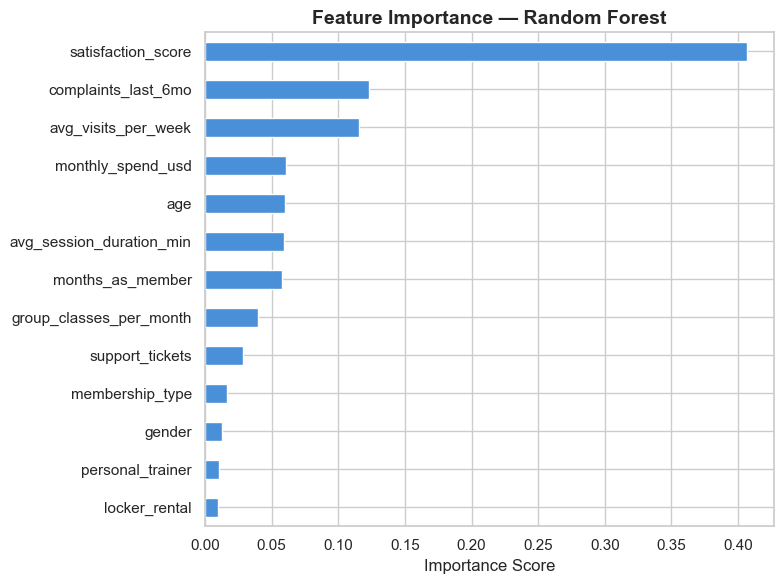

In [18]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind='barh', ax=ax, color='#4a90d9', edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

The Random Forest feature importance ranking reveals a clear hierarchy:

1. **`satisfaction_score`** — by far the dominant feature (40.7% importance).
   A single survey metric drives almost half of the model's predictive power.

2. **`complaints_last_6mo`** (12.3%) and **`avg_visits_per_week`** (11.5%) —
   behavioral signals that reflect actual engagement with the gym.

3. **`monthly_spend_usd`**, **`avg_session_duration_min`**, **`age`**, `months_as_member` —
   moderate contributors in the 5–6% range each.

4. **`gender`**, **`personal_trainer`**, **`locker_rental`** — minimal impact (<2% each).

> The bottom line: **how members feel** (satisfaction, complaints) and **how often they show up**
> are far more predictive than who they are demographically.

In [19]:
from sklearn.metrics import balanced_accuracy_score

for model, name in [(log_reg, 'Logistic Regression'), (rf, 'Random Forest')]:
    y_pred = model.predict(X_test)
    ba = balanced_accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    print(f"{name:25s} | Balanced Accuracy: {ba*100:.1f}%  | AUC: {auc:.3f}")

Logistic Regression       | Balanced Accuracy: 91.6%  | AUC: 0.970
Random Forest             | Balanced Accuracy: 87.6%  | AUC: 0.953


## 5. Conclusions

This project demonstrates that gym membership renewal can be predicted with high accuracy
using a small set of behavioral and satisfaction signals.

**Key findings:**

- The dataset is well-balanced (~50/50 split), making evaluation straightforward
- **Satisfaction score** is the single most powerful predictor — members who rate the gym
  highly are dramatically more likely to renew
- **Complaint frequency** is the strongest negative signal — even 2–3 complaints
  sharply reduce renewal probability
- **Visit frequency** matters more than session length — consistency beats intensity
- **Logistic Regression outperformed Random Forest** (AUC 0.970 vs 0.953),
  likely because the key features have roughly linear relationships with the target
- Annual membership holders renew at the *lowest* rate (46%), which is counterintuitive
  but suggests that long commitments create friction at renewal time

**Business implications:**

A gym could use this model to flag at-risk members 4–6 weeks before their renewal date,
trigger targeted retention campaigns (discounts, check-in calls, free PT sessions),
and ultimately reduce churn without guessing.

---
*Dataset: self-generated | Tools: Python 3, scikit-learn, pandas, seaborn, matplotlib*